# New Good Model

## Libraries

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.evaluation.metrics import block_ks_test


## MODEL & LOSS FUNCTION

In [10]:
# ==========================================
# 2. THE WIDE & DEEP NETWORK (SKIP CONNECTIONS)
# ==========================================
class WideAndDeepStudentTNet(tf.keras.Model):
    def __init__(self):
        super(WideAndDeepStudentTNet, self).__init__()
        
        # --- THE DEEP PATH (Non-Linear) ---
        # We use 'swish' (x * sigmoid(x)) because it draws perfectly smooth polynomials!
        self.hidden = tf.keras.layers.Dense(16, activation='swish')
        
        # --- THE WIDE PATH (Strictly Linear baselines we already proved) ---
        self.mu_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.sigma_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer=tf.keras.initializers.Constant(0.02))
        self.nu_linear = tf.keras.layers.Dense(1, activation='softplus', kernel_initializer='zeros', bias_initializer=tf.keras.initializers.Constant(10.9))
        
        # --- THE CURVE MODIFIERS (Outputs of the hidden layer) ---
        # These start at zero, meaning on Epoch 1, the network is PURELY LINEAR!
        self.mu_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.sigma_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.nu_curve = tf.keras.layers.Dense(1, activation='softplus', kernel_initializer='zeros', bias_initializer='zeros')

    def call(self, inputs):
        # 1. Calculate the curves
        h = self.hidden(inputs)
        
        # 2. Add the Strict Linear Baseline to the Smooth Non-Linear Curves!
        raw_mu = self.mu_linear(inputs) + self.mu_curve(h)
        raw_sigma = self.sigma_linear(inputs) + self.sigma_curve(h)
        # raw_mu = self.mu_linear(inputs)
        # raw_sigma = self.sigma_linear(inputs)
        raw_nu = self.nu_linear(inputs) + self.nu_curve(h)
        # raw_nu = self.nu_linear(inputs)

        # 3. Apply ReLU safety limits
        sigma = tf.nn.relu(raw_sigma) + 1e-6
        # nu = tf.nn.relu(raw_nu) + 2.1
        nu = raw_nu + 2.1
        
        return raw_mu, sigma, nu


# Loss Function
def nll_loss_fn(mu_pred, sigma_pred, nu_pred, y_target):
    dist = tfd.StudentT(df=nu_pred, loc=mu_pred, scale=sigma_pred)
    return -tf.reduce_mean(dist.log_prob(y_target))



In [11]:
# ==========================================
# 2. MODEL & LOSS FUNCTION
# ==========================================

class LinearStudentTNet(tf.keras.Model):
    def __init__(self):
        super(LinearStudentTNet, self).__init__()
        # self.mu_head = tf.keras.layers.Dense(1)
        # self.sigma_head = tf.keras.layers.Dense(1)
        # # self.nu_head = tf.keras.layers.Dense(1)
        # self.nu_head = tf.keras.layers.Dense(1, activation='softplus')
    # 1. Initialize Mu to start exactly at a flat 0.0
        self.mu_head = tf.keras.layers.Dense(
            1, 
            kernel_initializer='zeros', 
            bias_initializer='zeros'
        )
        
        # 2. Initialize Sigma to start at a flat 0.02
        self.sigma_head = tf.keras.layers.Dense(
            1, 
            kernel_initializer='zeros', 
            bias_initializer=tf.keras.initializers.Constant(0.02)
        )
        
        # 3. Initialize Nu to start at a flat 5.1 (2.9 bias + 2.1 shift)
        # This keeps the tails fat enough to avoid blowing up on early outliers
        self.nu_head = tf.keras.layers.Dense(
            1, 
            activation='softplus',
            kernel_initializer='zeros', 
            bias_initializer=tf.keras.initializers.Constant(7.9)
        )

    def call(self, inputs):
        mu = self.mu_head(inputs)
        raw_sigma = self.sigma_head(inputs)
        sigma = tf.nn.relu(raw_sigma) + 1e-6
        
        nu = self.nu_head(inputs) + 2.1

        # raw_nu = self.nu_head(inputs) + 2.1
        # nu = tf.nn.relu(raw_nu) + 2.1

        return mu, sigma, nu


## GENERATE TRAIN & TEST DATA (Extrapolating Time)

In [12]:
from datetime import date
from src.data.data_loader import fetch_asset_data
from src.features.features import rolling_t_fit, features_lags, create_features

start_date = date(2015, 12, 31)
# start_date = date(2022, 12, 31)
end_date = date(2025, 12, 31)
window_size = 22 * 6
porcentage_train = 0.6
# model_classes = {'BTC-USD': 'Basic', 'ARKK': 'Residual', 'USO': 'Basic'} USDCLP=X
# ticker = 'USO'
# ticker = 'USDCLP=X'

ticker = 'BTC-USD'

df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
if ticker == 'USDCLP=X':
    df.loc[df.prices < 200, 'prices'] = 680

df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
df_vix = (df_vix[['prices']]) / np.sqrt(252)
df_vix.columns = ['VIX']
df_features = create_features(df, df_vix, window_size, n_lags=2)
df_features.dropna(inplace=True)
df_features = df_features.astype('float32')
df_y = df_features['returns']
df_X = df_features.drop(columns=['returns'])


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [13]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
# model = WideAndDeepStudentTNet()


In [14]:
n_train = int(porcentage_train * len(df_X))

test_window = 22 * 1
epochs = 500
count = 0
# epochs = 500

print("Training Wide & Deep Network on Polynomial Data...")

pit_values_test_total = []
dates_test_total = pd.Series([])

pred_sigma_test_total = np.array([])
pred_nu_test_total = np.array([])
pred_mu_test_total = np.array([])

while n_train < len(df_X):
    print('-'*30)
    print(n_train, len(df_X))
    print('-'*30)
    model = LinearStudentTNet()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.015) 
    
    @tf.function
    def train_step(X_batch, y_batch):
        with tf.GradientTape() as tape:
            mu, sigma, nu = model(X_batch)
            loss = nll_loss_fn(mu, sigma, nu, y_batch)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    df_X_train = df_X.iloc[:n_train]
    df_y_train = df_y.iloc[:n_train]
    
    df_X_test = df_X.iloc[n_train:n_train + test_window]
    df_y_test = df_y.iloc[n_train:n_train + test_window]

    X_train = tf.convert_to_tensor(np.matrix(df_X_train))
    y_train = tf.convert_to_tensor(np.matrix(df_y_train))
    X_test = tf.convert_to_tensor(np.matrix(df_X_test))
    y_test = tf.convert_to_tensor(np.matrix(df_y_test))

    for epoch in range(epochs):
        loss = train_step(X_train, y_train)
        if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | NLL Loss: {loss.numpy():.4f}")

    # Test results
    pred_mu_test, pred_sigma_test, pred_nu_test = model(X_test)
    dates_test_total = pd.concat([dates_test_total, pd.Series(df_X_test.index)])  #= np.hstack((dates_test_total, df_X_test.index))
    # dates_test_total = np.hstack((dates_test_total, df_X_test.index))
    # 1. Force predictions to be flat 1D tensors of shape (326,)
    pred_mu_flat = tf.reshape(pred_mu_test, [-1])
    pred_sigma_flat = tf.reshape(pred_sigma_test, [-1])
    pred_nu_flat = tf.reshape(pred_nu_test, [-1])

    pred_mu_test_total = np.hstack((pred_mu_test_total, pred_mu_flat))
    pred_sigma_test_total = np.hstack((pred_sigma_test_total, pred_sigma_flat))
    pred_nu_test_total = np.hstack((pred_nu_test_total, pred_nu_flat))

    # 2. Force the targets to be a flat 1D tensor of shape (326,)
    y_test_flat = tf.reshape(y_test, [-1])

    # 3. Create the distribution with the flattened parameters
    test_dist = tfd.StudentT(
        df=pred_nu_flat, 
        loc=pred_mu_flat, 
        scale=pred_sigma_flat
    )
    pit_values_test_total = np.hstack((pit_values_test_total, test_dist.cdf(y_test_flat).numpy()))
    n_train += test_window
    


Training Wide & Deep Network on Polynomial Data...
------------------------------
2112 3520
------------------------------
Epoch 000 | NLL Loss: 31.4713
Epoch 100 | NLL Loss: 3.9106
Epoch 200 | NLL Loss: 3.3139
Epoch 300 | NLL Loss: 3.0430
Epoch 400 | NLL Loss: 2.9134


C:\Users\fe_ma\AppData\Local\Temp\ipykernel_9000\2927404206.py:51: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  dates_test_total = pd.concat([dates_test_total, pd.Series(df_X_test.index)])  #= np.hstack((dates_test_total, df_X_test.index))


------------------------------
2134 3520
------------------------------
Epoch 000 | NLL Loss: 31.5193
Epoch 100 | NLL Loss: 3.8797
Epoch 200 | NLL Loss: 3.3164
Epoch 300 | NLL Loss: 3.0533
Epoch 400 | NLL Loss: 2.9221
------------------------------
2156 3520
------------------------------
Epoch 000 | NLL Loss: 31.5101
Epoch 100 | NLL Loss: 3.8891
Epoch 200 | NLL Loss: 3.3069
Epoch 300 | NLL Loss: 3.0414
Epoch 400 | NLL Loss: 2.9129
------------------------------
2178 3520
------------------------------
Epoch 000 | NLL Loss: 31.5099
Epoch 100 | NLL Loss: 3.8721
Epoch 200 | NLL Loss: 3.3017
Epoch 300 | NLL Loss: 3.0344
Epoch 400 | NLL Loss: 2.9065
------------------------------
2200 3520
------------------------------
Epoch 000 | NLL Loss: 31.5734
Epoch 100 | NLL Loss: 3.8833
Epoch 200 | NLL Loss: 3.3070
Epoch 300 | NLL Loss: 3.0431
Epoch 400 | NLL Loss: 2.9149
------------------------------
2222 3520
------------------------------
Epoch 000 | NLL Loss: 31.5729
Epoch 100 | NLL Loss: 3.88

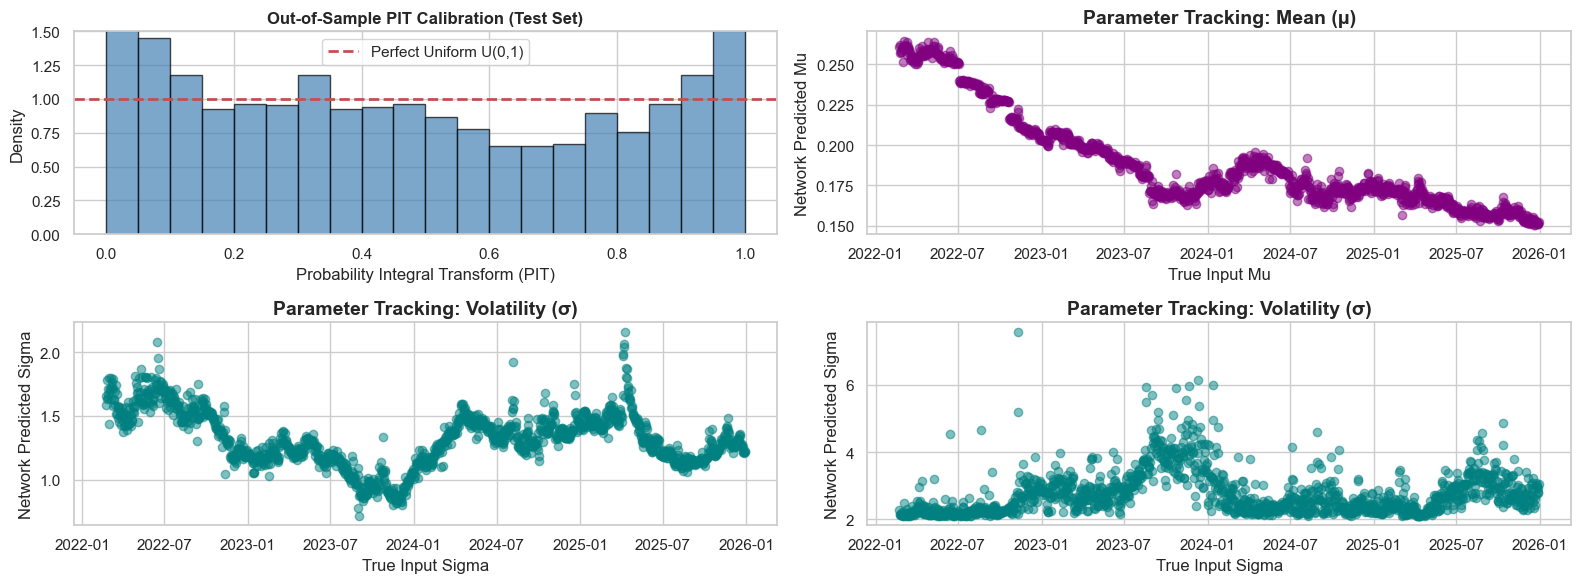


--- INDEPENDENT BLOCK TEST SUMMARY (1408-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2022-02-22,2025-12-30,0.062363,0.000033,❌ FAILED


In [15]:
# Set up the Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 6))

# --- PANEL 2: Out-of-Sample PIT Histogram ---
axes[0, 0].hist(pit_values_test_total, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
axes[0, 0].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform U(0,1)")
axes[0, 0].set_title("Out-of-Sample PIT Calibration (Test Set)", fontweight='bold')
axes[0, 0].set_xlabel("Probability Integral Transform (PIT)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_ylim(0, 1.5)
axes[0, 0].legend()

# --- Plot 2: Parameter Accuracy (Mu) ---
# A perfect model will align all points on the red dashed 45-degree line
axes[0, 1].scatter(dates_test_total, pred_mu_test_total, alpha=0.5, color="purple")
# axes[0, 1].plot([min(true_mu_test), max(true_mu_test)], [min(true_mu_test), max(true_mu_test)], 'r--', lw=2) 
axes[0, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("True Input Mu")
axes[0, 1].set_ylabel("Network Predicted Mu")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 0].scatter(dates_test_total, pred_sigma_test_total, alpha=0.5, color="teal")
# axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("True Input Sigma")
axes[1, 0].set_ylabel("Network Predicted Sigma")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 1].scatter(dates_test_total, pred_nu_test_total, alpha=0.5, color="teal")
# axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 1].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("True Input Sigma")
axes[1, 1].set_ylabel("Network Predicted Sigma")

plt.tight_layout()
plt.show()

df_pit_values_test = pd.DataFrame(pit_values_test_total, index=dates_test_total, columns=['PIT'])
block_ks_test(df_pit_values_test['PIT'], block_size=len(df_pit_values_test))

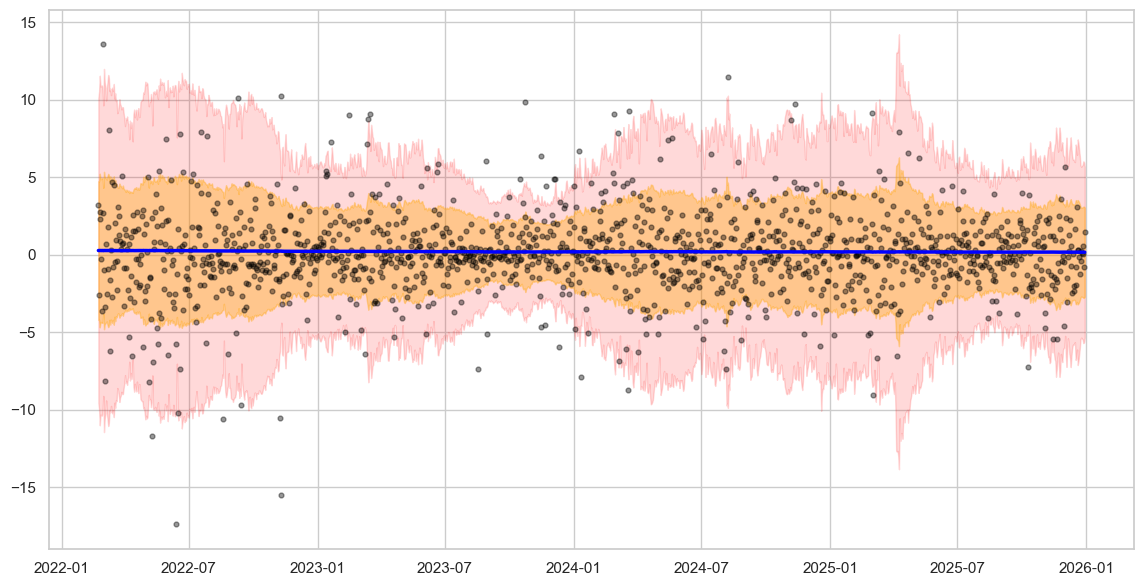

In [16]:

# 3. Create the distribution with the flattened parameters
test_dist = tfd.StudentT(
    df=pred_nu_test_total, 
    loc=pred_mu_test_total, 
    scale=pred_sigma_test_total
)

n_train = int(porcentage_train * len(df_X))
df_y_test = df_y.iloc[n_train:]
y_test = tf.convert_to_tensor(np.matrix(df_y_test))
y_test_flat = tf.reshape(y_test, [-1])

q_01 = test_dist.quantile(0.01).numpy()
q_05 = test_dist.quantile(0.05).numpy()
q_95 = test_dist.quantile(0.95).numpy()
q_99 = test_dist.quantile(0.99).numpy()

# 3. Set up the plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# --- PLOT THE RISK BANDS ---
# Plot the 1% to 99% Extreme Tail Risk interval (Light Red)
plt.fill_between(
    dates_test_total, q_01, q_99, 
    color='red', alpha=0.15, 
    label='1% - 99% Extreme Risk Band'
)

# Plot the 5% to 95% Standard Risk interval (Orange)
plt.fill_between(
    dates_test_total, q_05, q_95, 
    color='orange', alpha=0.35, 
    label='5% - 95% Standard Risk Band'
)

# --- PLOT THE DATA & MEAN ---
# Plot the raw, noisy market data
plt.scatter(
    dates_test_total, y_test_flat, 
    color='black', s=12, alpha=0.4, 
    label='Actual Market Returns'
)

# Plot the predicted center (Mu)
plt.plot(
    dates_test_total, pred_mu_test_total, 
    color='blue', lw=2.5, 
    label='Predicted Mean ($\mu_t$)'
)

